# Loan Approval Prediction - Exploratory Data Analysis

This notebook performs EDA and preprocessing on the Loan Approval Dataset.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load Data

In [9]:
df = pd.read_csv('../data/raw/loan_approval_data.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (50000, 20)


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


## 2. Basic Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,34.957060,11.118603,18.000,26.000,35.000,43.00000,70.000
years_employed,50000.0,7.454868,7.612097,0.000,1.300,4.900,11.40000,39.900
annual_income,50000.0,50062.892040,32630.501014,15000.000,27280.500,41607.500,62723.25000,250000.000
credit_score,50000.0,643.614820,64.731518,348.000,600.000,643.000,687.00000,850.000
credit_history_years,50000.0,8.168274,7.207552,0.000,2.000,6.100,12.60000,30.000
savings_assets,50000.0,3595.619400,13232.399398,0.000,130.000,568.000,2271.00000,300000.000
current_debt,50000.0,14290.442220,13243.757493,60.000,5581.000,10385.000,18449.25000,163344.000
defaults_on_file,50000.0,0.053480,0.224991,0.000,0.000,0.000,0.00000,1.000
delinquencies_last_2yrs,50000.0,0.554640,0.845050,0.000,0.000,0.000,1.00000,9.000
derogatory_marks,50000.0,0.147640,0.412996,0.000,0.000,0.000,0.00000,4.000


In [12]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

## 3. Target Variable Analysis

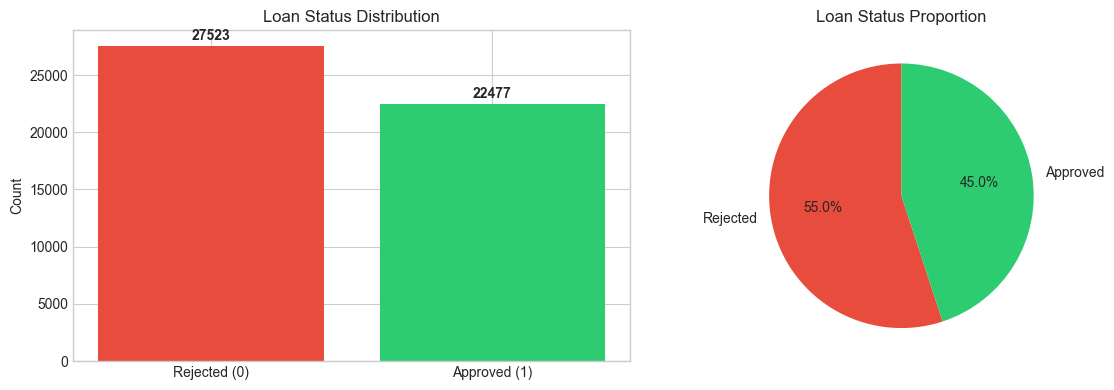

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['loan_status'].value_counts()
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(['Rejected (0)', 'Approved (1)'], target_counts.values, color=colors)
axes[0].set_title('Loan Status Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Rejected', 'Approved'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Loan Status Proportion')

plt.tight_layout()
plt.savefig('../report/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Numerical Features Distribution

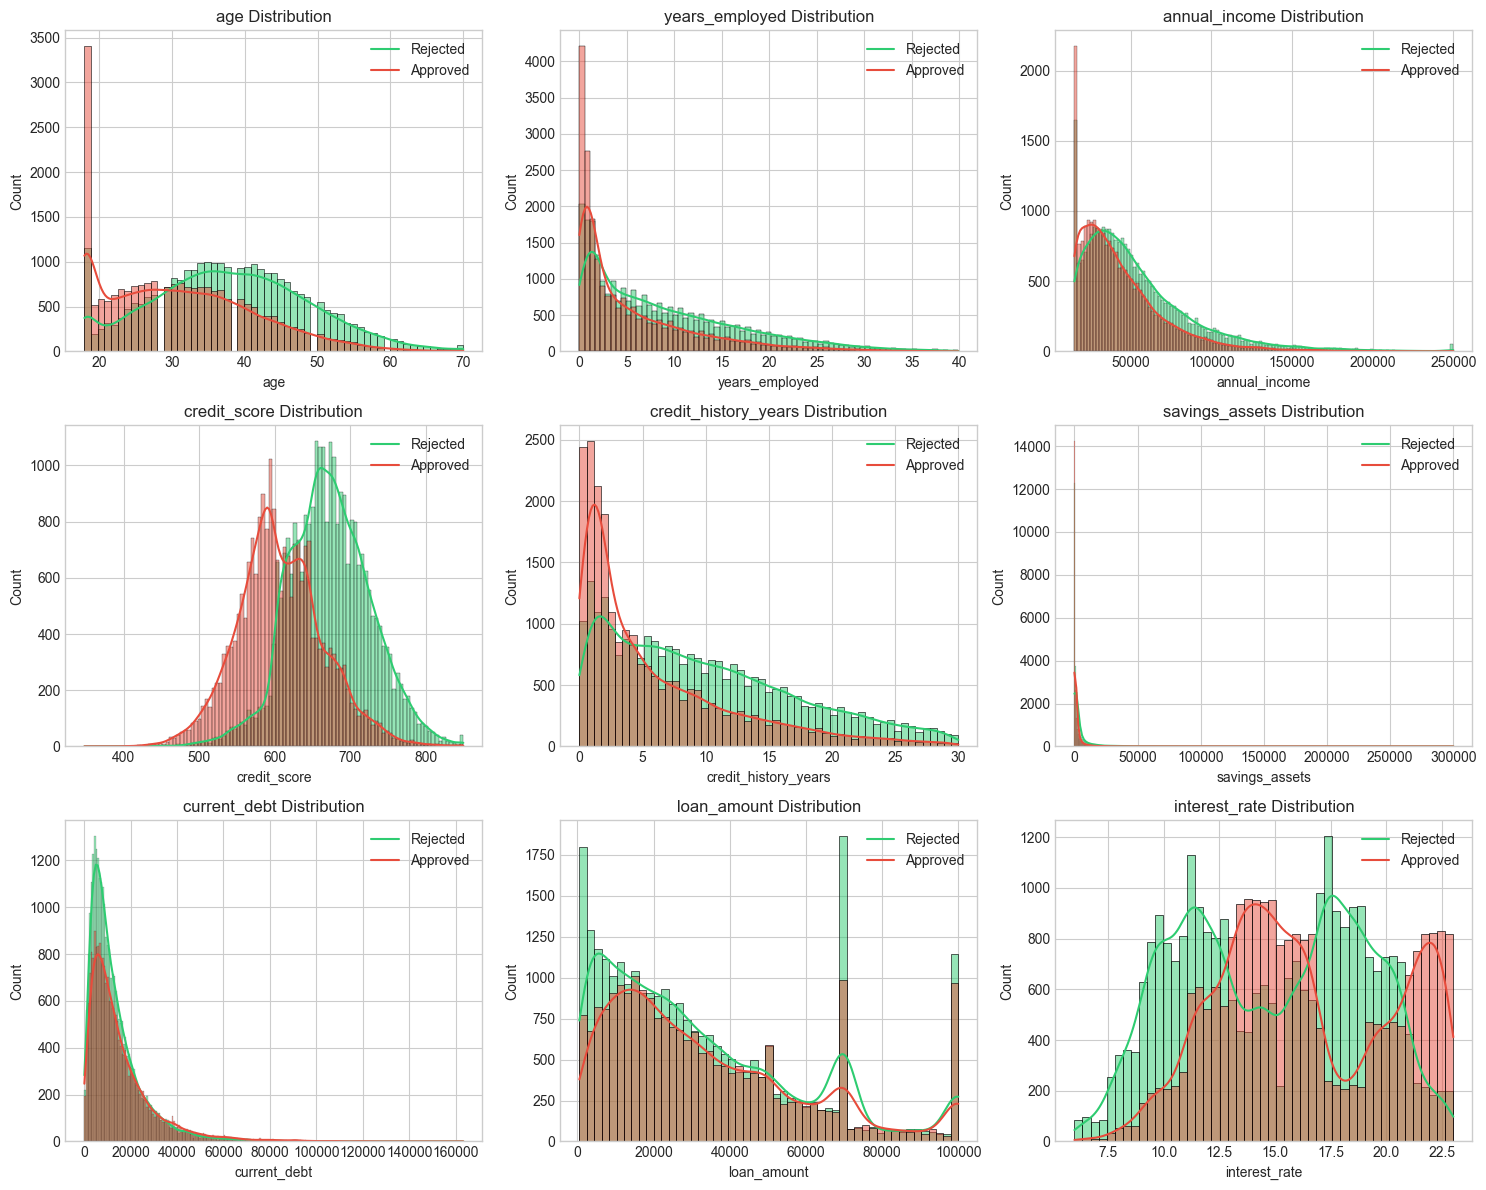

In [7]:
numerical_cols = ['age', 'years_employed', 'annual_income', 'credit_score', 
                  'credit_history_years', 'savings_assets', 'current_debt',
                  'loan_amount', 'interest_rate']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='loan_status', kde=True, ax=axes[idx], palette=colors)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].legend(['Rejected', 'Approved'])

plt.tight_layout()
plt.savefig('../report/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Features Analysis

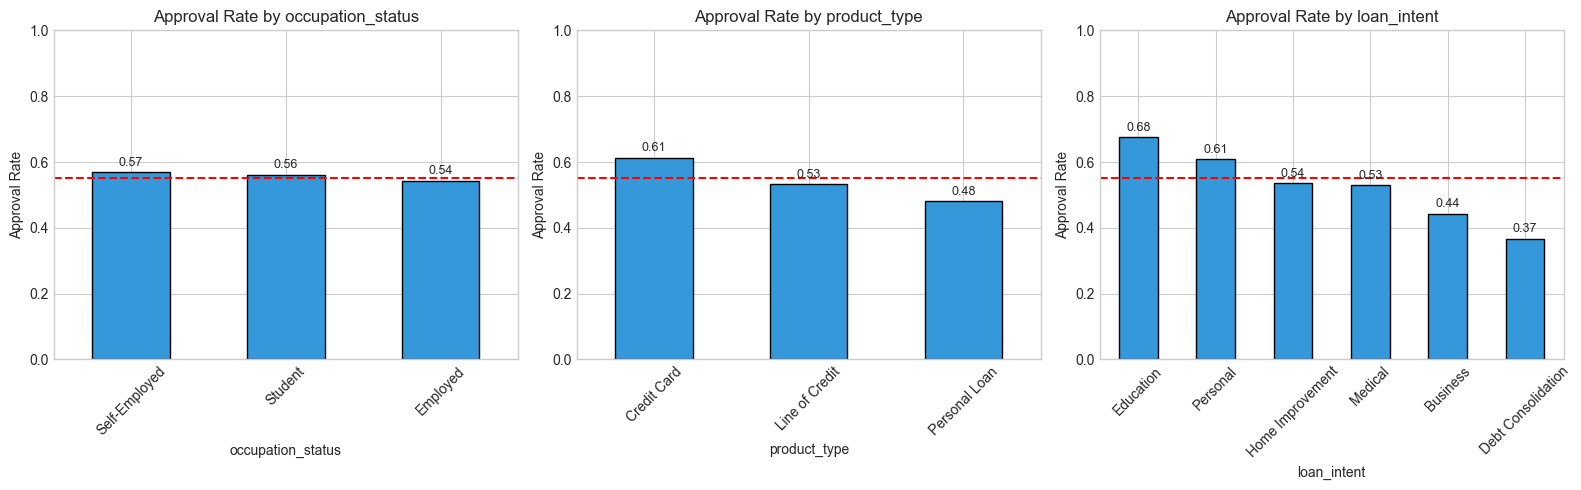

In [14]:
categorical_cols = ['occupation_status', 'product_type', 'loan_intent']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(categorical_cols):
    approval_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    approval_rate.plot(kind='bar', ax=axes[idx], color='#3498db', edgecolor='black')
    axes[idx].set_title(f'Approval Rate by {col}')
    axes[idx].set_ylabel('Approval Rate')
    axes[idx].set_ylim(0, 1)
    axes[idx].axhline(y=0.55, color='red', linestyle='--', label='Overall Rate')
    for i, v in enumerate(approval_rate.values):
        axes[idx].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../report/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

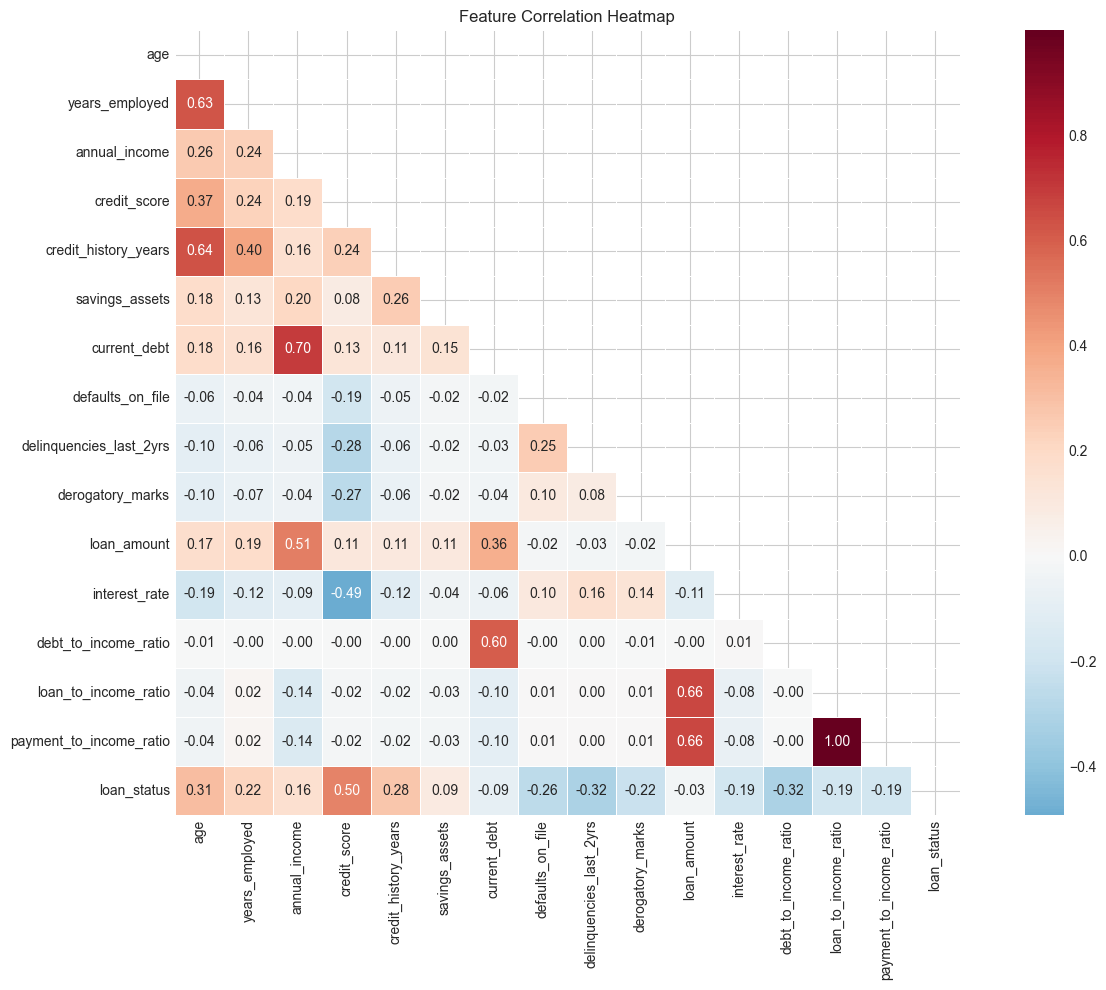

In [15]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

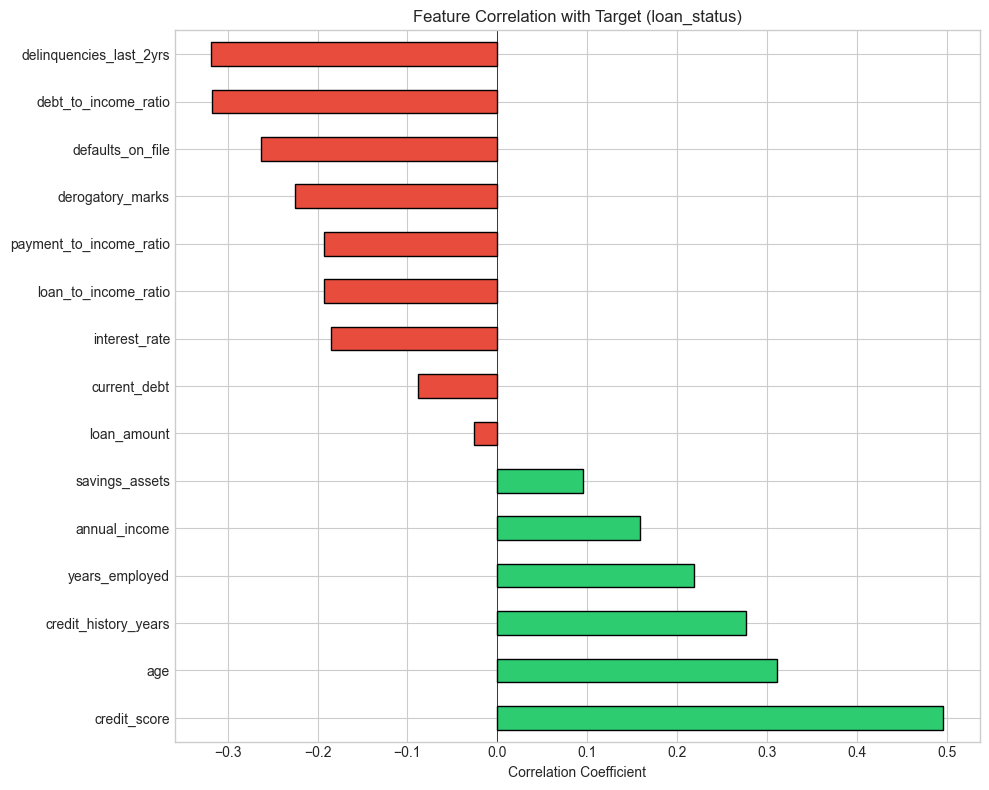

In [16]:
target_corr = numeric_df.corr()['loan_status'].drop('loan_status').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors_corr = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors_corr, edgecolor='black')
plt.title('Feature Correlation with Target (loan_status)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../report/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Features Deep Dive

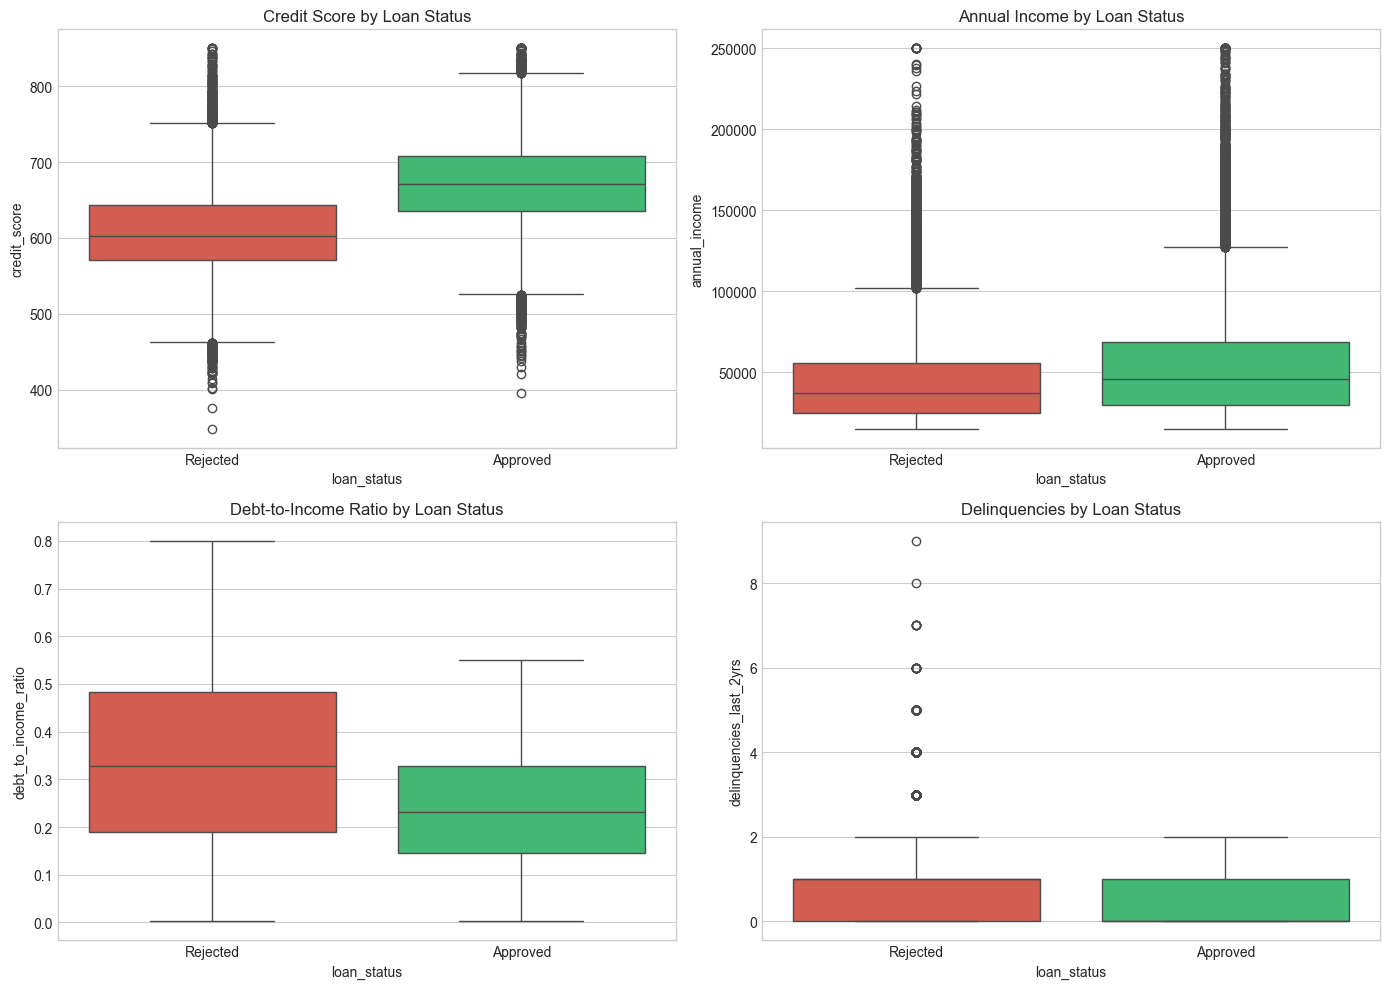

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='loan_status', y='credit_score', data=df, ax=axes[0, 0], palette=colors)
axes[0, 0].set_title('Credit Score by Loan Status')
axes[0, 0].set_xticklabels(['Rejected', 'Approved'])

sns.boxplot(x='loan_status', y='annual_income', data=df, ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Annual Income by Loan Status')
axes[0, 1].set_xticklabels(['Rejected', 'Approved'])

sns.boxplot(x='loan_status', y='debt_to_income_ratio', data=df, ax=axes[1, 0], palette=colors)
axes[1, 0].set_title('Debt-to-Income Ratio by Loan Status')
axes[1, 0].set_xticklabels(['Rejected', 'Approved'])

sns.boxplot(x='loan_status', y='delinquencies_last_2yrs', data=df, ax=axes[1, 1], palette=colors)
axes[1, 1].set_title('Delinquencies by Loan Status')
axes[1, 1].set_xticklabels(['Rejected', 'Approved'])

plt.tight_layout()
plt.savefig('../report/key_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Derived Features Verification

In [18]:
df['calc_dti'] = df['current_debt'] / df['annual_income']
df['calc_lti'] = df['loan_amount'] / df['annual_income']

print("debt_to_income_ratio vs current_debt/annual_income:")
print(f"Match: {(abs(df['debt_to_income_ratio'] - df['calc_dti']) < 0.01).mean():.2%}")

print("\nloan_to_income_ratio vs loan_amount/annual_income:")
print(f"Match: {(abs(df['loan_to_income_ratio'] - df['calc_lti']) < 0.01).mean():.2%}")

df = df.drop(columns=['calc_dti', 'calc_lti'])

debt_to_income_ratio vs current_debt/annual_income:
Match: 100.00%

loan_to_income_ratio vs loan_amount/annual_income:
Match: 100.00%


## 9. Data Preprocessing

In [19]:
drop_columns = ['customer_id', 'current_debt']
df_processed = df.drop(columns=drop_columns)
print(f"Dropped columns: {drop_columns}")
print(f"Shape after dropping: {df_processed.shape}")

Dropped columns: ['customer_id', 'current_debt']
Shape after dropping: (50000, 18)


In [20]:
categorical_cols = ['occupation_status', 'product_type', 'loan_intent']
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=False)
print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

Shape after encoding: (50000, 27)

New columns: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status', 'occupation_status_Employed', 'occupation_status_Self-Employed', 'occupation_status_Student', 'product_type_Credit Card', 'product_type_Line of Credit', 'product_type_Personal Loan', 'loan_intent_Business', 'loan_intent_Debt Consolidation', 'loan_intent_Education', 'loan_intent_Home Improvement', 'loan_intent_Medical', 'loan_intent_Personal']


In [21]:
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget distribution in train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Target distribution in test: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set: (40000, 26)
Test set: (10000, 26)

Target distribution in train: {1: 0.55, 0: 0.45}
Target distribution in test: {1: 0.55, 0: 0.45}


In [22]:
numerical_features = ['age', 'years_employed', 'annual_income', 'credit_score',
                      'credit_history_years', 'savings_assets', 'defaults_on_file',
                      'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount',
                      'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio',
                      'payment_to_income_ratio']

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Scaling complete!")
X_train.head()

Scaling complete!


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,occupation_status_Employed,occupation_status_Self-Employed,occupation_status_Student,product_type_Credit Card,product_type_Line of Credit,product_type_Personal Loan,loan_intent_Business,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal
16708,0.457030,0.876320,0.838253,0.550555,-0.522050,-0.265137,-0.239387,-0.658275,-0.356590,-0.261334,-0.852250,-0.412282,-0.779402,-0.779343,False,True,False,False,False,True,False,False,True,False,False,False
9237,-1.521668,-0.981170,-0.462362,-0.068767,-0.966298,-0.248281,-0.239387,0.527058,-0.356590,0.166329,-0.135218,-1.320377,0.787505,0.789652,True,False,False,False,False,True,False,False,True,False,False,False
2214,-0.532319,0.257157,-0.712979,-0.750022,-0.369340,-0.255847,4.177342,0.527058,-0.356590,0.735274,0.002767,-0.687842,2.680226,2.680162,True,False,False,False,False,True,False,False,False,False,False,True
14496,-0.712201,-0.783564,-0.748387,-0.827437,-0.341575,-0.239142,-0.239387,-0.658275,-0.356590,-1.078476,0.101329,-1.151284,-1.105216,-1.107289,False,False,True,False,False,True,False,True,False,False,False,False
27659,-1.521668,-0.981170,-0.746792,-1.168065,-0.883002,-0.268732,4.177342,0.527058,2.067132,-0.318610,-0.007089,-0.950876,0.556006,0.558161,True,False,False,False,False,True,False,False,False,False,True,False


## 10. Save Processed Data

In [23]:
os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

joblib.dump(scaler, '../data/processed/scaler.pkl')
joblib.dump(numerical_features, '../data/processed/numerical_features.pkl')
joblib.dump(X_train.columns.tolist(), '../data/processed/feature_names.pkl')

print("Saved:")
print("  - X_train.csv, X_test.csv")
print("  - y_train.csv, y_test.csv")
print("  - scaler.pkl")
print("  - numerical_features.pkl")
print("  - feature_names.pkl")

Saved:
  - X_train.csv, X_test.csv
  - y_train.csv, y_test.csv
  - scaler.pkl
  - numerical_features.pkl
  - feature_names.pkl


## Summary

**Dataset:** 50,000 loan applications with 20 features

**Key Findings:**
- Target is fairly balanced (55% approved, 45% rejected)
- Credit score has strongest positive correlation (+0.50)
- Delinquencies and debt-to-income ratio have strongest negative correlation (~-0.32)
- Education loans have highest approval rate (67%)
- Debt consolidation loans have lowest approval rate (37%)

**Preprocessing:**
- Dropped: customer_id (identifier), current_debt (redundant with ratio)
- One-hot encoded: occupation_status, product_type, loan_intent
- Scaled numerical features using StandardScaler
- Final features: 26